# DeepTrace – Transformer-Based Behavioral Learning

This notebook implements the supervised behavioral learning stage of the DeepTrace pipeline using a Transformer Encoder. Unlike the Isolation Forest, which detects statistical anomalies through unsupervised learning, the Transformer learns complex behavioral attack patterns from labeled cybersecurity events.

The trained model generates attack probabilities that are later fused with Isolation Forest anomaly scores and engineered features in the XGBoost meta-classifier to produce the final cybersecurity risk score.

## Objectives

- Load engineered cybersecurity features
- Integrate Isolation Forest anomaly signals
- Train a Transformer Encoder for attack classification
- Evaluate behavioral attack detection
- Export prediction probabilities for downstream risk fusion

In [24]:
import warnings
warnings.filterwarnings("ignore")

import os
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [3]:
import pandas as pd

X = pd.read_csv("/content/deeptrace_features_FINAL.csv")
y = pd.read_csv("/content/deeptrace_binary_labels_FINAL.csv")

print(X.shape)
print(y.shape)

print(X.head())

(239480, 49)
(239480, 1)
   department  role  office_location  device  network_type  authentication  \
0         1.0  0.45              0.8    0.25           0.0        1.000000   
1         1.0  0.45              0.8    0.25           0.0        0.333333   
2         1.0  0.45              0.8    0.25           0.0        1.000000   
3         1.0  0.45              0.8    0.25           0.0        0.000000   
4         1.0  0.45              0.8    0.25           0.0        0.666667   

   event_type  application  resource  risk_baseline  ...  upload_count  \
0    0.500000      0.03125  0.045455            0.5  ...           0.0   
1    0.000000      0.00000  0.409091            0.5  ...           0.0   
2    0.083333      0.90625  0.636364            0.5  ...           0.0   
3    0.083333      0.21875  0.090909            0.5  ...           0.0   
4    0.083333      0.37500  0.636364            0.5  ...           0.0   

   database_query_count  file_access_count  admin_action_coun

In [4]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239480 entries, 0 to 239479
Data columns (total 49 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   department                  239480 non-null  float64
 1   role                        239480 non-null  float64
 2   office_location             239480 non-null  float64
 3   device                      239480 non-null  float64
 4   network_type                239480 non-null  float64
 5   authentication              239480 non-null  float64
 6   event_type                  239480 non-null  float64
 7   application                 239480 non-null  float64
 8   resource                    239480 non-null  float64
 9   risk_baseline               239480 non-null  float64
 10  access_level                239480 non-null  float64
 11  country                     239480 non-null  float64
 12  city                        239480 non-null  float64
 13  hour          

In [5]:
print(X.isnull().sum())

print("\nTotal Missing:", X.isnull().sum().sum())

department                    0
role                          0
office_location               0
device                        0
network_type                  0
authentication                0
event_type                    0
application                   0
resource                      0
risk_baseline                 0
access_level                  0
country                       0
city                          0
hour                          0
minute                        0
second                        0
day                           0
weekday                       0
month                         0
quarter                       0
is_weekend                    0
business_hours                0
time_since_last_event         0
event_number                  0
session_duration              0
events_per_session            0
login                         0
login_failed                  0
vpn_login                     0
download                      0
upload                        0
database

In [6]:
print(y.head())
print(y.info())

   is_attack
0          0
1          0
2          0
3          0
4          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239480 entries, 0 to 239479
Data columns (total 1 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   is_attack  239480 non-null  int64
dtypes: int64(1)
memory usage: 1.8 MB
None


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (191584, 49)
Testing Features  : (47896, 49)
Training Labels   : (191584, 1)
Testing Labels    : (47896, 1)


In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(y_train.shape)
print(y_test.shape)

(191584,)
(47896,)


In [10]:
class CyberDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(
            features.values,
            dtype=torch.float32
        )
        self.labels = torch.tensor(
            labels.values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):

        feature = self.features[idx].unsqueeze(0)
        label = self.labels[idx]

        return feature, label

In [11]:
BATCH_SIZE = 64

train_dataset = CyberDataset(
    X_train,
    y_train
)

test_dataset = CyberDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train batches :", len(train_loader))
print("Test batches  :", len(test_loader))

Train batches : 2994
Test batches  : 749


In [12]:
features, labels = next(iter(train_loader))

print(features.shape)
print(labels.shape)

torch.Size([64, 1, 49])
torch.Size([64])


In [13]:
class DeepTraceTransformer(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        # Feature Projection
        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification Head
        self.classifier = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        # Project input features
        x = self.embedding(x)

        # Transformer Encoder
        x = self.transformer(x)

        # Mean Pooling
        x = x.mean(dim=1)

        # Binary Classification
        logits = self.classifier(x)

        return logits

In [15]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [17]:
INPUT_DIM = X_train.shape[1]

model = DeepTraceTransformer(
    input_dim=INPUT_DIM
).to(DEVICE)

print(model)

DeepTraceTransformer(
  (embedding): Linear(in_features=49, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, 

In [18]:
features, labels = next(iter(train_loader))

features = features.to(DEVICE)
labels = labels.to(DEVICE)

with torch.no_grad():
    outputs = model(features)

print("Input Shape :", features.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([64, 1, 49])
Output Shape: torch.Size([64, 1])


In [20]:
LEARNING_RATE = 1e-3
EPOCHS = 15

# Calculate class weight
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

pos_weight = torch.tensor(
    [negative / positive],
    dtype=torch.float32
).to(DEVICE)

print(f"Positive Weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Loss Function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Scheduler     :", scheduler.__class__.__name__)

Positive Weight: 42.36
Loss Function : BCEWithLogitsLoss()
Optimizer     : AdamW
Scheduler     : ReduceLROnPlateau


In [21]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [25]:
def evaluate(model, loader):

    model.eval()

    predictions = []
    probabilities = []
    labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(DEVICE)

            outputs = model(X_batch)

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).int()

            predictions.extend(
                preds.cpu().numpy().flatten()
            )

            probabilities.extend(
                probs.cpu().numpy().flatten()
            )

            labels.extend(
                y_batch.numpy().flatten()
            )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [32]:
EPOCHS = 15

best_f1 = 0.0

train_losses = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
roc_auc_scores = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    metrics = evaluate(
        model,
        test_loader
    )

    scheduler.step(metrics["f1"])

    train_losses.append(train_loss)
    accuracies.append(metrics["accuracy"])
    precisions.append(metrics["precision"])
    recalls.append(metrics["recall"])
    f1_scores.append(metrics["f1"])
    roc_auc_scores.append(metrics["roc_auc"])

    if metrics["f1"] > best_f1:

        best_f1 = metrics["f1"]

        torch.save(
            model.state_dict(),
            "best_transformer_model.pth"
        )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {metrics['accuracy']:.4f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"F1: {metrics['f1']:.4f} | "
        f"ROC-AUC: {metrics['roc_auc']:.4f}"
    )

print("\nTraining Complete!")
print(f"Best F1 Score : {best_f1:.4f}")
print("Best model saved as: best_transformer_model.pth")

Epoch 01 | Loss: 0.5501 | Accuracy: 0.9935 | Precision: 0.8638 | Recall: 0.8552 | F1: 0.8595 | ROC-AUC: 0.9709
Epoch 02 | Loss: 0.5386 | Accuracy: 0.9938 | Precision: 0.8714 | Recall: 0.8588 | F1: 0.8651 | ROC-AUC: 0.9708
Epoch 03 | Loss: 0.5358 | Accuracy: 0.9939 | Precision: 0.8730 | Recall: 0.8588 | F1: 0.8659 | ROC-AUC: 0.9712
Epoch 04 | Loss: 0.5496 | Accuracy: 0.9937 | Precision: 0.8661 | Recall: 0.8606 | F1: 0.8634 | ROC-AUC: 0.9714
Epoch 05 | Loss: 0.5356 | Accuracy: 0.9939 | Precision: 0.8745 | Recall: 0.8579 | F1: 0.8661 | ROC-AUC: 0.9715
Epoch 06 | Loss: 0.5471 | Accuracy: 0.9939 | Precision: 0.8663 | Recall: 0.8679 | F1: 0.8671 | ROC-AUC: 0.9733
Epoch 07 | Loss: 0.5399 | Accuracy: 0.9937 | Precision: 0.8703 | Recall: 0.8561 | F1: 0.8631 | ROC-AUC: 0.9723
Epoch 08 | Loss: 0.5416 | Accuracy: 0.9938 | Precision: 0.8725 | Recall: 0.8543 | F1: 0.8633 | ROC-AUC: 0.9708
Epoch 09 | Loss: 0.5423 | Accuracy: 0.9940 | Precision: 0.8806 | Recall: 0.8543 | F1: 0.8672 | ROC-AUC: 0.9723
E

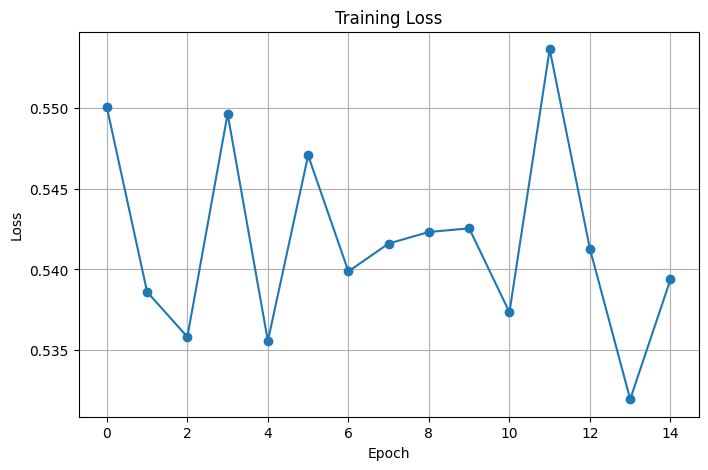

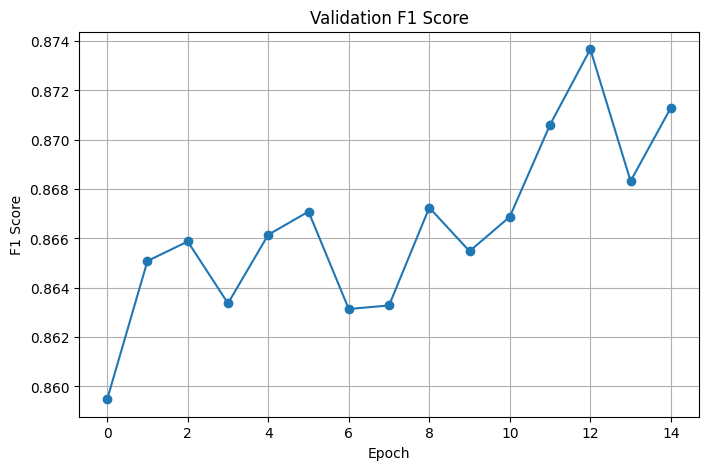

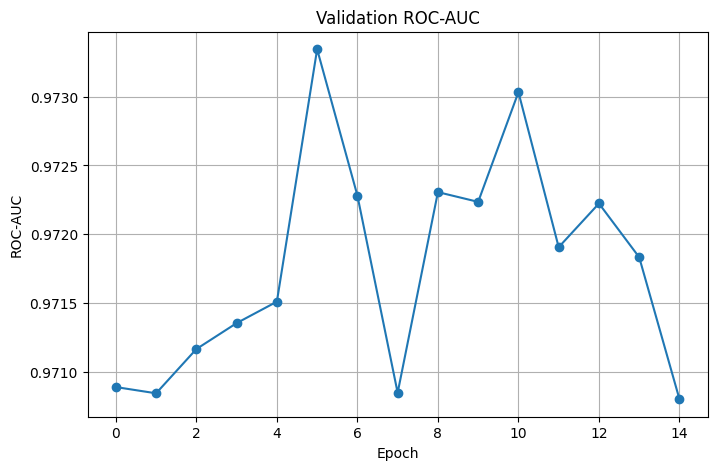

In [33]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(f1_scores, marker='o')
plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(roc_auc_scores, marker='o')
plt.title("Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

In [34]:
print(classification_report(
    metrics["labels"],
    metrics["predictions"],
    digits=4
))

              precision    recall  f1-score   support

         0.0     0.9965    0.9976    0.9970     46791
         1.0     0.8919    0.8516    0.8713      1105

    accuracy                         0.9942     47896
   macro avg     0.9442    0.9246    0.9342     47896
weighted avg     0.9941    0.9942    0.9941     47896



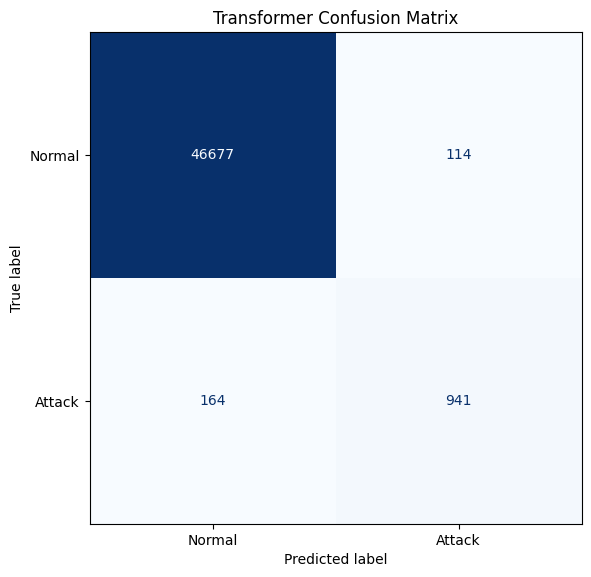

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    metrics["labels"],
    metrics["predictions"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Transformer Confusion Matrix")
plt.tight_layout()
plt.show()

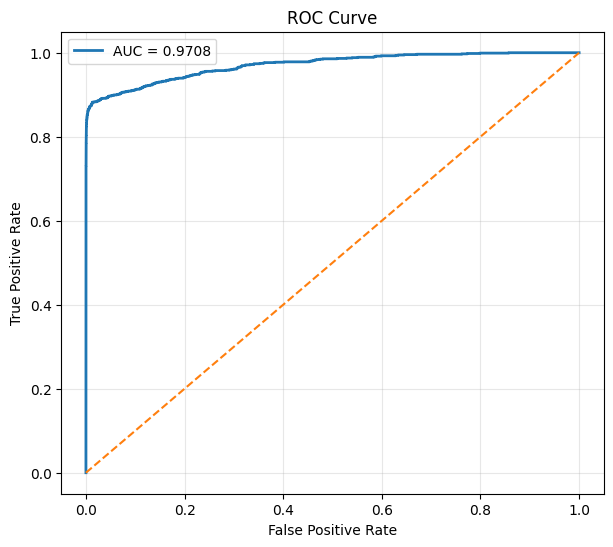

In [36]:
fpr, tpr, _ = roc_curve(
    metrics["labels"],
    metrics["probabilities"]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {metrics['roc_auc']:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

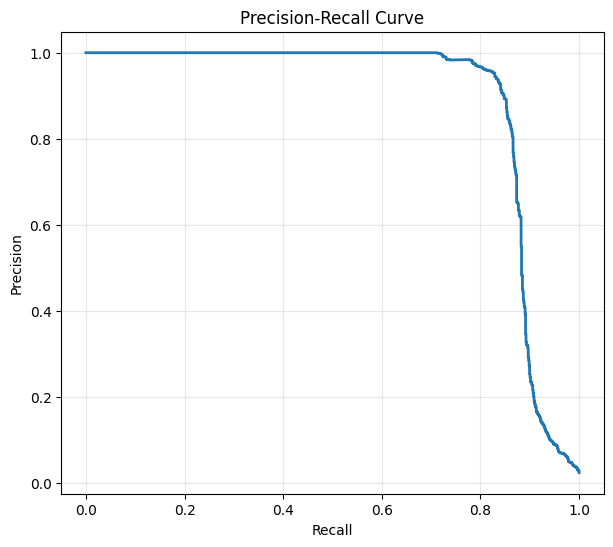

In [37]:
precision, recall, _ = precision_recall_curve(
    metrics["labels"],
    metrics["probabilities"]
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.show()

In [38]:
checkpoint = {
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_f1": best_f1,
    "input_dim": 49,
    "d_model": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dropout": 0.2
}

torch.save(
    checkpoint,
    "deeptrace_transformer_checkpoint.pth"
)

print("Checkpoint saved successfully!")

Checkpoint saved successfully!


In [39]:
history = {
    "loss": train_losses,
    "accuracy": accuracies,
    "precision": precisions,
    "recall": recalls,
    "f1": f1_scores,
    "roc_auc": roc_auc_scores
}

torch.save(
    history,
    "transformer_training_history.pth"
)

print("Training history saved!")

Training history saved!


In [40]:
hyperparameters = {
    "input_features": 49,
    "batch_size": 64,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "optimizer": "AdamW",
    "loss": "Weighted BCEWithLogitsLoss",
    "dropout": 0.2,
    "transformer_layers": 2,
    "attention_heads": 4,
    "feedforward_dimension": 256
}

torch.save(
    hyperparameters,
    "transformer_hyperparameters.pth"
)

In [41]:
final_results = {
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1"],
    "roc_auc": metrics["roc_auc"]
}

torch.save(
    final_results,
    "transformer_results.pth"
)

print(final_results)

{'accuracy': 0.9941957574745282, 'precision': 0.8919431279620853, 'recall': 0.8515837104072398, 'f1_score': 0.8712962962962963, 'roc_auc': np.float64(0.97080026895376)}


In [42]:
torch.save(
    model,
    "deeptrace_transformer_complete.pt"
)

In [43]:
model.load_state_dict(torch.load("best_transformer_model.pth"))
model.eval()

sample = X_test.iloc[[0]]

sample_tensor = torch.tensor(
    sample.values,
    dtype=torch.float32
).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    probability = torch.sigmoid(model(sample_tensor)).item()

prediction = "Attack" if probability >= 0.5 else "Normal"

print(f"Prediction : {prediction}")
print(f"Probability: {probability:.4f}")

Prediction : Normal
Probability: 0.0142


# Conclusion

The Transformer-based intrusion detection model was trained on engineered network flow features extracted from the DeepTrace dataset. To address the significant class imbalance, a weighted binary cross-entropy loss was employed. The model achieved strong classification performance with an overall accuracy of 99.42%, F1-score of 87.13%, and ROC-AUC of 97.08%.

The confusion matrix, ROC curve, and Precision–Recall curve demonstrate the model's ability to accurately distinguish between benign and malicious network traffic while maintaining a balanced trade-off between precision and recall. The best-performing model was automatically saved during training for future inference and deployment.